In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from glob import glob
from PIL import Image
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
ROOT_DIR   = "../data/20_trees"
IMAGES_ROOT = os.path.join(ROOT_DIR, "Images")
GT_ROOT     = os.path.join(ROOT_DIR, "Ground_truths")

CLASS_META = {
    0: ("Other",       "#78909C"),
    1: ("Background",  "#4A5568"),
    2: ("Bark",        "#8D6E63"),
    3: ("Wood",        "#D4A96A"),
    4: ("Knot",        "#FF6F00"),
    5: ("Crack",       "#E53935"),
}

DARK_BG  = "#0F1117"
PANEL_BG = "#1A1D27"
TEXT_COL = "#E8E8F0"
GRID_COL = "#2A2D3A"
ACCENT   = "#F0A500"

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    PANEL_BG,
    "axes.edgecolor":    GRID_COL,
    "axes.labelcolor":   TEXT_COL,
    "axes.titlecolor":   TEXT_COL,
    "xtick.color":       TEXT_COL,
    "ytick.color":       TEXT_COL,
    "text.color":        TEXT_COL,
    "grid.color":        GRID_COL,
    "grid.linewidth":    0.5,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

def label(c): return CLASS_META.get(c, (f"Class {c}", "#999999"))[0]
def color(c): return CLASS_META.get(c, (f"Class {c}", "#999999"))[1]

In [3]:
# mapping from mask log prefix to actual image log prefix
PREFIX_OVERRIDE = {}
def mask_stem_to_image_stem(mask_filename):
    name  = os.path.splitext(mask_filename)[0]
    parts = name.split("_", 2)
    stem  = parts[2] if len(parts) == 3 else name

    # check if this stem's prefix needs remapping
    for wrong_prefix, correct_prefix in PREFIX_OVERRIDE.items():
        if stem.startswith(wrong_prefix):
            stem = correct_prefix + stem[len(wrong_prefix):]
            break

    return stem

image_paths = sorted(glob(os.path.join(IMAGES_ROOT, "**", "*.tif"), recursive=True))

mask_paths = sorted(glob(
    os.path.join(GT_ROOT, "**", "GroundTruthProject", "PixelLabelData", "*.png"),
    recursive=True
))

image_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}

pairs = []
orphaned_masks = []
for mp in mask_paths:
    stem = mask_stem_to_image_stem(os.path.basename(mp))
    if stem in image_lookup:
        pairs.append((image_lookup[stem], mp))
    else:
        orphaned_masks.append(mp)

kmen_masked = [img for img, _ in pairs if "kmen" in img]
dub_masked  = [img for img, _ in pairs if "Dub"  in img]

print(f"Total images    : {len(image_paths)}")
print(f"Total masks     : {len(mask_paths)}")
print(f"Matched pairs   : {len(pairs)}")
print(f"  Kmen pairs    : {len(kmen_masked)}")
print(f"  Dub pairs     : {len(dub_masked)}")
print(f"Orphaned masks  : {len(orphaned_masks)}")
if orphaned_masks:
    print("\nStill orphaned:")
    for mp in orphaned_masks[:5]:
        print(f"  {os.path.basename(mp)}")

Total images    : 1347
Total masks     : 1347
Matched pairs   : 1347
  Kmen pairs    : 704
  Dub pairs     : 643
Orphaned masks  : 0


In [4]:
pixel_counts      = defaultdict(int)
image_has_class   = defaultdict(int)
image_sizes       = []
intensity_hist    = np.zeros(256, dtype=np.int64)
class_pixel_areas = defaultdict(list)
all_classes       = set()
class_intensity_hists = {}

for img_path, mask_path in pairs:
    img  = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path))

    # ensure mask matches image size
    if mask.shape != img.shape:
        mask = np.array(
            Image.fromarray(mask).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST
            )
        )

    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    intensity_hist += hist

    # per-class intensity histogram
    for c in np.unique(mask):
        class_pixels = img[mask == c]
        if c not in class_intensity_hists:
            class_intensity_hists[c] = np.zeros(256, dtype=np.int64)
        h, _ = np.histogram(class_pixels, bins=256, range=(0, 256))
        class_intensity_hists[c] += h

    image_sizes.append(img.shape)
    classes_present = np.unique(mask)
    all_classes.update(classes_present.tolist())
    total_px = mask.size

    for c in classes_present:
        cnt = int(np.sum(mask == c))
        pixel_counts[c] += cnt
        image_has_class[c] += 1
        class_pixel_areas[c].append(cnt / total_px * 100)

    for c in CLASS_META:
        if c not in classes_present:
            class_pixel_areas[c].append(0.0)

all_classes      = sorted(all_classes)
n_images         = len(pairs)
total_px_all     = sum(pixel_counts.values())
colors_ordered   = [color(c) for c in all_classes]
labels_ordered   = [label(c) for c in all_classes]
heights          = [s[0] for s in image_sizes]
widths           = [s[1] for s in image_sizes]

print("Class pixel counts:")
for c in all_classes:
    pct = pixel_counts[c] / total_px_all * 100
    print(f"  {label(c):12s}  {pixel_counts[c]:>12,} px  ({pct:.2f}%)")

Class pixel counts:
  Other                  248 px  (0.00%)
  Background     646,044,696 px  (79.77%)
  Bark            12,899,545 px  (1.59%)
  Wood           150,450,770 px  (18.58%)
  Knot               330,791 px  (0.04%)
  Crack              123,146 px  (0.02%)


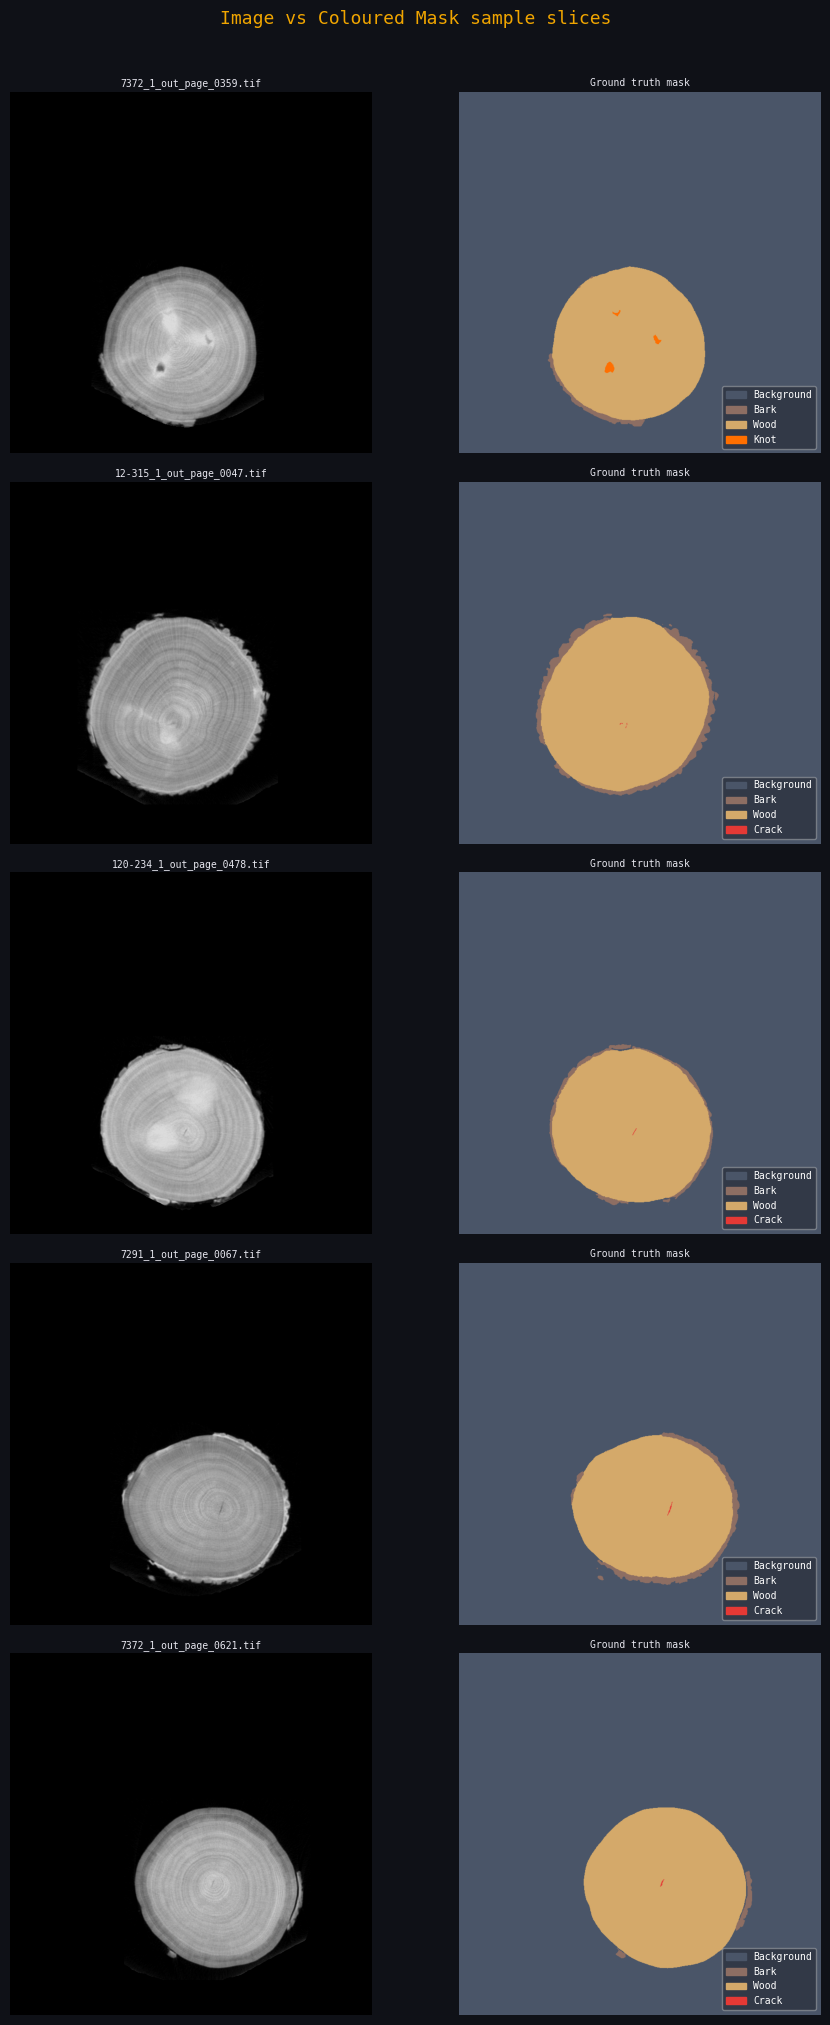

In [5]:
import random

N_SAMPLES = 5

sample_pairs = random.sample(pairs, min(N_SAMPLES, len(pairs)))

# Build a colour map: class index -> RGB (0-1)
def hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(10, N_SAMPLES * 4), facecolor=DARK_BG)
if N_SAMPLES == 1:
    axes = [axes]  # keep iterable

for row, (img_path, mask_path) in enumerate(sample_pairs):
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path))

    # Build coloured mask image
    colour_mask = np.zeros((*mask.shape, 3), dtype=np.float32)
    for c in np.unique(mask):
        rgb = hex_to_rgb(color(c))
        colour_mask[mask == c] = rgb

    # Image
    ax_img = axes[row][0]
    ax_img.imshow(img)
    ax_img.set_title(os.path.basename(img_path), fontsize=7, pad=4)
    ax_img.axis("off")

    # Mask
    ax_msk = axes[row][1]
    ax_msk.imshow(colour_mask)
    ax_msk.set_title("Ground truth mask", fontsize=7, pad=4)
    ax_msk.axis("off")

    # Legend on the mask panel
    present_classes = np.unique(mask)
    legend_patches = [
        Patch(color=hex_to_rgb(color(c)), label=label(c))
        for c in present_classes
    ]
    ax_msk.legend(
        handles=legend_patches,
        fontsize=7, loc="lower right",
        framealpha=0.4, labelcolor="white",
        facecolor=DARK_BG
    )

plt.suptitle("Image vs Coloured Mask sample slices",
             fontsize=13, color=ACCENT, y=1.01)
plt.tight_layout()
plt.show()

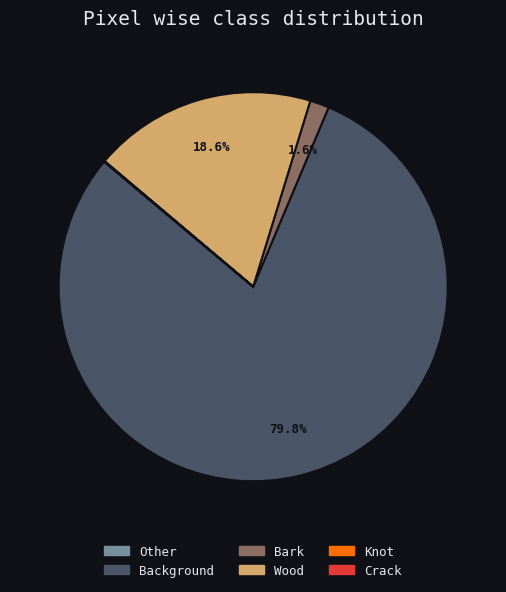

In [6]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK_BG)
px_vals = [pixel_counts[c] for c in all_classes]
wedges, texts, autotexts = ax.pie(
    px_vals,
    colors=colors_ordered,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    pctdistance=0.75,
    startangle=140,
    wedgeprops=dict(linewidth=1.5, edgecolor=DARK_BG),
)
for at in autotexts:
    at.set_color(DARK_BG); at.set_fontsize(9); at.set_fontweight("bold")
ax.set_title("Pixel wise class distribution", fontsize=14, pad=14)
ax.legend(
    handles=[Patch(color=colors_ordered[i]) for i in range(len(all_classes))],
    labels=labels_ordered,
    fontsize=9, loc="lower center", bbox_to_anchor=(0.5, -0.12),
    ncol=3, framealpha=0, labelcolor=TEXT_COL
)
plt.tight_layout()
plt.show()

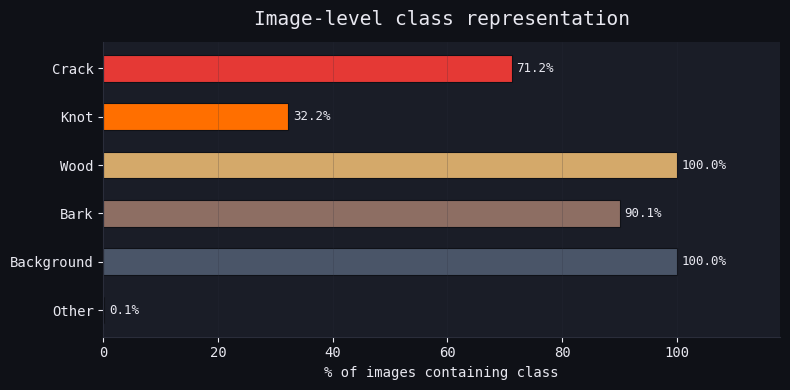

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=DARK_BG)
rep_pct = [image_has_class[c] / n_images * 100 for c in all_classes]
bars = ax.barh(labels_ordered, rep_pct, color=colors_ordered,
               edgecolor=DARK_BG, linewidth=0.8, height=0.55)
for bar, val in zip(bars, rep_pct):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9, color=TEXT_COL)
ax.set_xlim(0, 118)
ax.set_xlabel("% of images containing class")
ax.set_title("Image-level class representation", fontsize=14, pad=12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Key observations
- **Bark** is present in 90.1% of images - a high coverage rate
  suggesting most slices retain a visible bark ring, with only ~10%
  of slices being taken from positions where bark is absent or removed.
- **Crack** appears in 71.2% of images - the majority of slices
  contain at least one crack, making it the most common defect class
  by image representation.
- **Knot** appears in 32.2% of images - roughly 1 in 3 slices
  contains a knot, consistent with knots being spatially localised
  to branch junction zones along the log length.
- **Other** is present in 0.1% of images - can be safely merged into Background or ignored entirely.

### Implications for modelling
- With Crack present in 71.2% of images there is reasonable image-level
  coverage for learning crack features - the challenge remains at the
  pixel level where cracks are still extremely sparse.
- Knot at 32.2% means roughly 2 in 3 images contain no knot at all -
  oversampling of knot-positive images during training is important
  to prevent the model from underlearning this class.
- The high Bark coverage (90.1%) means the model will see plenty of
  bark examples - the risk here is the model confusing the dark bark
  ring with crack regions given their overlapping intensity ranges.
- **Other** can be excluded from the loss function entirely given its
  negligible presence.

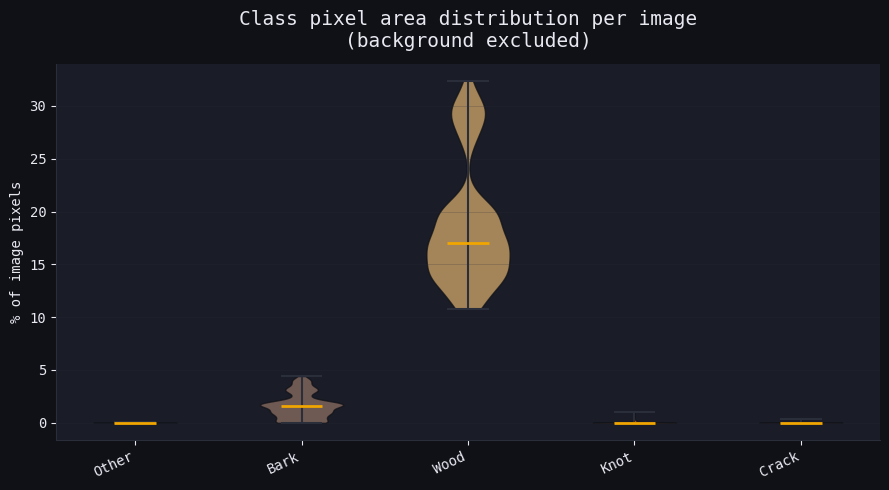

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=DARK_BG)

EXCLUDE_FROM_VIOLIN = {1}  # Background class index

non_trivial = [(i, c) for i, c in enumerate(all_classes)
               if any(v > 0 for v in class_pixel_areas[c])
               and c not in EXCLUDE_FROM_VIOLIN]

vd = [class_pixel_areas[c] for _, c in non_trivial]
vp = ax.violinplot(vd, positions=range(len(non_trivial)),
                   showmedians=True, showextrema=True)
for pc, (_, c) in zip(vp["bodies"], non_trivial):
    pc.set_facecolor(color(c)); pc.set_alpha(0.75); pc.set_edgecolor(DARK_BG)
vp["cmedians"].set_color(ACCENT); vp["cmedians"].set_linewidth(2)
for part in ["cbars", "cmins", "cmaxes"]:
    vp[part].set_color(GRID_COL)
ax.set_xticks(range(len(non_trivial)))
ax.set_xticklabels([label(c) for _, c in non_trivial], rotation=25, ha="right", fontsize=10)
ax.set_ylabel("% of image pixels")
ax.set_title("Class pixel area distribution per image\n(background excluded)", fontsize=14, pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

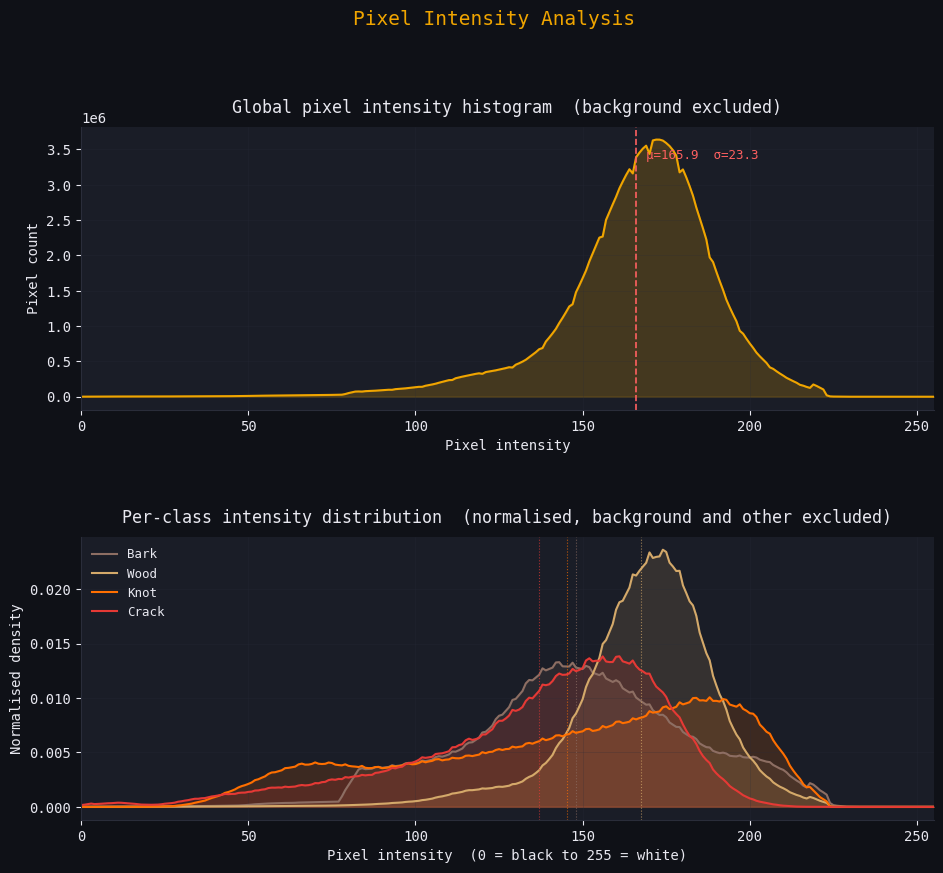

In [9]:
EXCLUDE_FROM_INTENSITY = {0, 1}  # Background class index

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9), facecolor=DARK_BG,
                                      gridspec_kw={"hspace": 0.45})
x = np.arange(256)

# global histogram (background excluded)
filtered_hist = intensity_hist.copy()
if 1 in class_intensity_hists:
    filtered_hist = intensity_hist - class_intensity_hists[1]

smoothed = np.convolve(filtered_hist, np.ones(4) / 4, mode="same")
ax_top.fill_between(x, smoothed, alpha=0.2, color=ACCENT)
ax_top.plot(x, smoothed, color=ACCENT, linewidth=1.5)
mean_i = float(np.average(x, weights=filtered_hist))
std_i  = float(np.sqrt(np.average((x - mean_i) ** 2, weights=filtered_hist)))
ax_top.axvline(mean_i, color="#FF6060", linewidth=1.2, linestyle="--")
ax_top.text(mean_i + 3, ax_top.get_ylim()[1] * 0.88,
            f"μ={mean_i:.1f}  σ={std_i:.1f}", color="#FF6060", fontsize=9)
ax_top.set_xlim(0, 255)
ax_top.set_xlabel("Pixel intensity")
ax_top.set_ylabel("Pixel count")
ax_top.set_title("Global pixel intensity histogram  (background excluded)", fontsize=12, pad=10)
ax_top.grid(alpha=0.3)

# per-class normalised curves (background excluded)
for c, hist in class_intensity_hists.items():
    if c in EXCLUDE_FROM_INTENSITY:
        continue
    if hist.sum() == 0:
        continue
    smoothed_c = np.convolve(hist, np.ones(6) / 6, mode="same")
    norm = smoothed_c / smoothed_c.sum()
    ax_bot.fill_between(x, norm, alpha=0.15, color=color(c))
    ax_bot.plot(x, norm, color=color(c), linewidth=1.5, label=label(c))
    median_c = float(np.average(x, weights=hist))
    ax_bot.axvline(median_c, color=color(c), linewidth=0.8, linestyle=":", alpha=0.7)

ax_bot.set_xlim(0, 255)
ax_bot.set_xlabel("Pixel intensity  (0 = black to 255 = white)")
ax_bot.set_ylabel("Normalised density")
ax_bot.set_title("Per-class intensity distribution  (normalised, background and other excluded)", fontsize=12, pad=10)
ax_bot.legend(fontsize=9, framealpha=0, labelcolor=TEXT_COL, loc="upper left")
ax_bot.grid(alpha=0.3)

plt.suptitle("Pixel Intensity Analysis", fontsize=14, color=ACCENT, y=1.01)
plt.tight_layout()
plt.show()

### Global histogram (background excluded)
- The distribution is unimodal and slightly left-skewed, centred at
  **μ=166.9** with **σ=23.3**.
- The distribution is clean and well-behaved with no near-zero spike
- The left tail (100-150) represents darker tissue - bark, knot edges,
  and crack shadows - while the right shoulder (180–210) represents
  bright, dense wood grain.
- σ=23.5 is relatively small - the dataset has consistent scanner
  brightness with moderate internal contrast variation.

### Per-class intensity distributions

| Class | Approx. peak | Spread   |
|-------|-------------|----------|
| Wood  | ~175        | Narrow   |
| Knot  | ~165        | Medium   |
| Bark  | ~148        | Wide     |
| Crack | ~140        | Widest   |

### Key finding - substantial class overlap
All four classes overlap heavily in the **130–180 intensity range**.
This range contains meaningful pixels from every class simultaneously,
confirming that intensity threshold alone cannot discriminate defects from
normal tissue. The model must rely on spatial context, texture
gradients and shape to make correct predictions instead.

### Implications for modelling
- The unimodal global distribution with σ=23.5 confirms the
  combined dataset is **well-suited to standard normalisation** -
  however given the per-batch difference (Kmen μ=160.8 vs Dub μ=169.2)
  per-image normalisation might still be better over dataset-level
  statistics to handle batch-to-batch variation.
- Crack's extension toward intensity 0 means **very dark pixels are
  informative** and should never be clipped or normalised away during
  preprocessing.
- The Knot–Wood overlap (both peaking in 160–180) confirms that knot
  detection will rely almost entirely on **shape and spatial context**
  rather than brightness. A compact, circular dark region within
  bright wood is the key discriminating feature here.

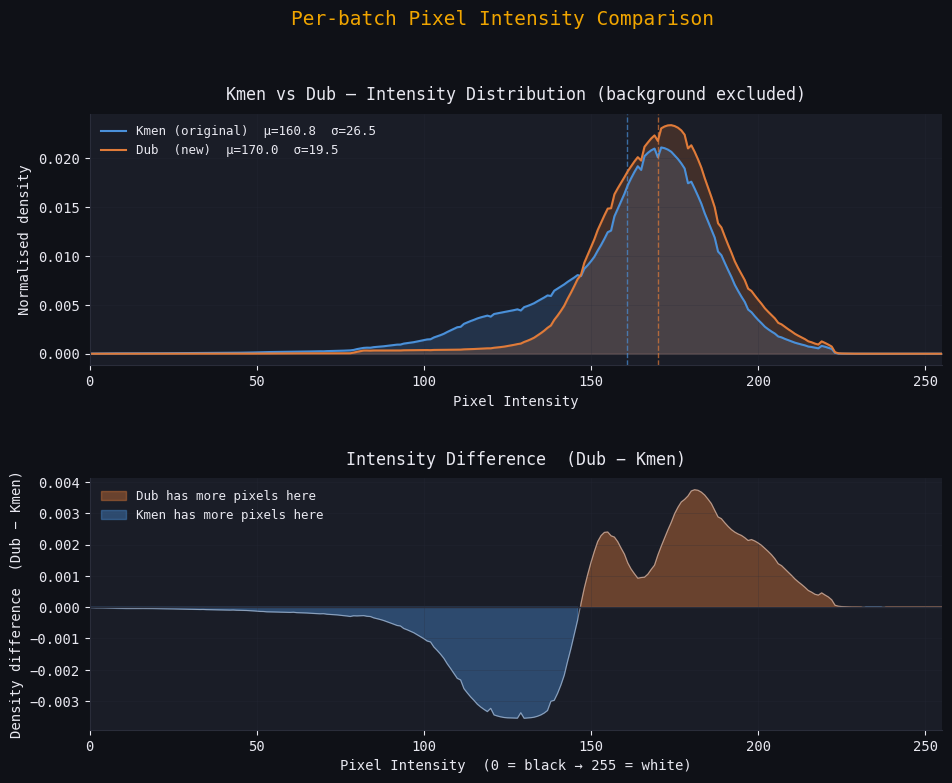

In [10]:
EXCLUDE_CLASSES = [1]  # Background — use list not set

kmen_hist = np.zeros(256, dtype=np.int64)
dub_hist  = np.zeros(256, dtype=np.int64)

for img_path, mask_path in pairs:
    img  = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path))

    if mask.shape != img.shape:
        mask = np.array(
            Image.fromarray(mask).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST
            )
        )

    valid_pixels = img[~np.isin(mask, EXCLUDE_CLASSES)]
    hist, _ = np.histogram(valid_pixels, bins=256, range=(0, 256))

    if "kmen" in img_path:
        kmen_hist += hist
    else:
        dub_hist  += hist

x = np.arange(256)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), facecolor=DARK_BG,
                                gridspec_kw={"hspace": 0.45})

# top: overlaid normalised curves
for hist, name, col in [
    (kmen_hist, "Kmen (original)", "#4A90D9"),
    (dub_hist,  "Dub  (new)",      "#E07B39"),
]:
    smoothed = np.convolve(hist, np.ones(4) / 4, mode="same")
    norm     = smoothed / smoothed.sum()
    mean_i   = float(np.average(x, weights=hist))
    std_i    = float(np.sqrt(np.average((x - mean_i) ** 2, weights=hist)))
    ax1.fill_between(x, norm, alpha=0.2, color=col)
    ax1.plot(x, norm, color=col, linewidth=1.5,
             label=f"{name}  μ={mean_i:.1f}  σ={std_i:.1f}")
    ax1.axvline(mean_i, color=col, linewidth=1.0, linestyle="--", alpha=0.7)

ax1.set_xlim(0, 255)
ax1.set_xlabel("Pixel Intensity")
ax1.set_ylabel("Normalised density")
ax1.set_title("Kmen vs Dub — Intensity Distribution (background excluded)",
              fontsize=12, pad=10)
ax1.legend(fontsize=9, framealpha=0, labelcolor=TEXT_COL)
ax1.grid(alpha=0.3)

# bottom: difference curve
kmen_norm = np.convolve(kmen_hist, np.ones(4)/4, mode="same")
kmen_norm = kmen_norm / kmen_norm.sum()
dub_norm  = np.convolve(dub_hist,  np.ones(4)/4, mode="same")
dub_norm  = dub_norm  / dub_norm.sum()

diff = dub_norm - kmen_norm
ax2.fill_between(x, diff, where=(diff >= 0), alpha=0.4, color="#E07B39",
                 label="Dub has more pixels here")
ax2.fill_between(x, diff, where=(diff < 0),  alpha=0.4, color="#4A90D9",
                 label="Kmen has more pixels here")
ax2.plot(x, diff, color=TEXT_COL, linewidth=0.8, alpha=0.5)
ax2.axhline(0, color=GRID_COL, linewidth=1.0)
ax2.set_xlim(0, 255)
ax2.set_xlabel("Pixel Intensity  (0 = black → 255 = white)")
ax2.set_ylabel("Density difference  (Dub − Kmen)")
ax2.set_title("Intensity Difference  (Dub − Kmen)", fontsize=12, pad=10)
ax2.legend(fontsize=9, framealpha=0, labelcolor=TEXT_COL)
ax2.grid(alpha=0.3)

plt.suptitle("Per-batch Pixel Intensity Comparison", fontsize=14, color=ACCENT, y=1.01)
plt.tight_layout()
plt.show()

## Per-batch Pixel Intensity Comparison (Kmen vs Dub)

| Batch | μ (mean) | σ (std dev) |
|-------|----------|-------------|
| Kmen  | 160.8    | 26.5        |
| Dub   | 170      | 19.5        |

### Key observations
- Kmen has significantly more pixels in the **100–150 range** (blue) -
  darker tissue regions that are largely absent in Dub logs. These
  are likely bark, knot, and crack pixels which are more prevalent
  in the kmen batch.
- Dub has more pixels in the **150–220 range** (orange) - brighter,
  more uniform wood tissue consistent with the higher mean and lower σ.
- The crossover point sits around intensity **150** - below this Kmen
  dominates, above this Dub dominates.

### Implications for modelling
- The 8.4 unit mean difference is large enough to matter - a model
  trained only on one batch could learn a brightness prior that
  does not transfer to the other.
- **Per-image normalisation** (subtract per-image mean, divide by
  per-image std) is strongly recommended over dataset-level
  normalisation - this will collapse the batch difference and make
  inputs comparable regardless of which scanner or log they came from.
- The tighter Dub distribution (lower σ) means the model will see
  less intensity variety from Dub images - brightness and contrast
  augmentation is especially important for Dub images to simulate
  the darker tissue regions the model will need to handle at inference.

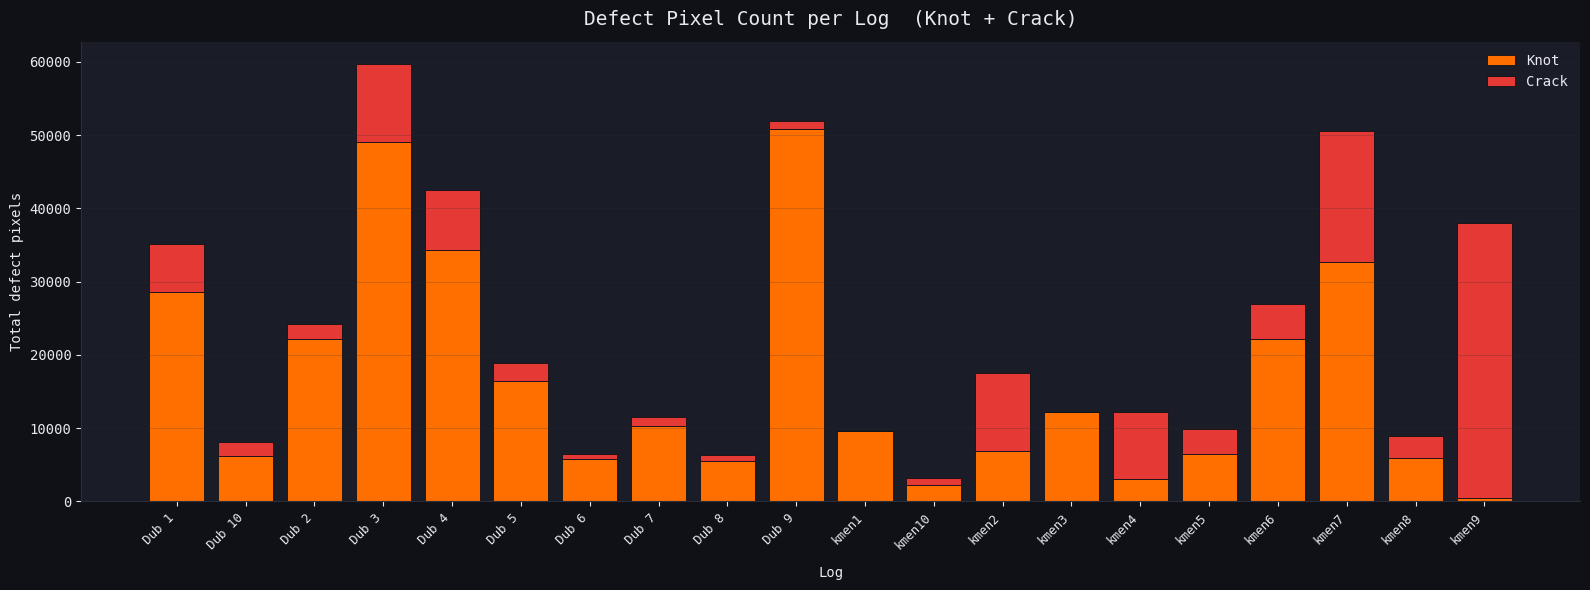

In [11]:
log_names = sorted([
    f for f in os.listdir(IMAGES_ROOT)
    if os.path.isdir(os.path.join(IMAGES_ROOT, f))
])
defect_classes = [c for c in all_classes if label(c) in ("Knot", "Crack")]
log_defect_pixels = {lg: defaultdict(int) for lg in log_names}

for img_path, mask_path in pairs:
    parts  = img_path.replace("\\", "/").split("/")
    log_id = next((p for p in parts if p in log_names), None)
    if log_id is None:
        continue
    mask = np.array(Image.open(mask_path))
    for c in defect_classes:
        log_defect_pixels[log_id][c] += int(np.sum(mask == c))

fig, ax = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
bottom = np.zeros(len(log_names))
for c in defect_classes:
    vals = np.array([log_defect_pixels[lg][c] for lg in log_names], dtype=float)
    ax.bar(log_names, vals, bottom=bottom, color=color(c),
           label=label(c), edgecolor=DARK_BG, linewidth=0.6)
    bottom += vals

ax.set_xlabel("Log", labelpad=10)
ax.set_ylabel("Total defect pixels")
ax.set_title("Defect Pixel Count per Log  (Knot + Crack)", fontsize=14, pad=12)
ax.set_xticks(range(len(log_names)))
ax.set_xticklabels(log_names, rotation=45, ha="right", fontsize=9)
ax.legend(fontsize=10, framealpha=0, labelcolor=TEXT_COL)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Defect Pixel Count per Log (Knot + Crack)

### Overview
Defect load varies dramatically across logs - from near-zero (kmen10)
to ~51,000 pixels (Dub 9), confirming that defect distribution is
highly uneven across both batches and individual logs.

### Defect type patterns across the full dataset
- **Knot dominant logs**: Dub 9, Dub 1, kmen7, kmen6
- **Crack dominant logs**: kmen9, kmen2, Dub 4
- **Mixed**: Dub 2, Dub 5, kmen3
- **Near-zero defects**: kmen10

### Implications for modelling
- The high variance across logs makes **log-stratified splitting
  essential**.
- It is necessary to include at least one high-defect log from each defect type
  (knot dominant and crack dominant) in both train and validation splits. Dub3, Dub 9 and kmen9.

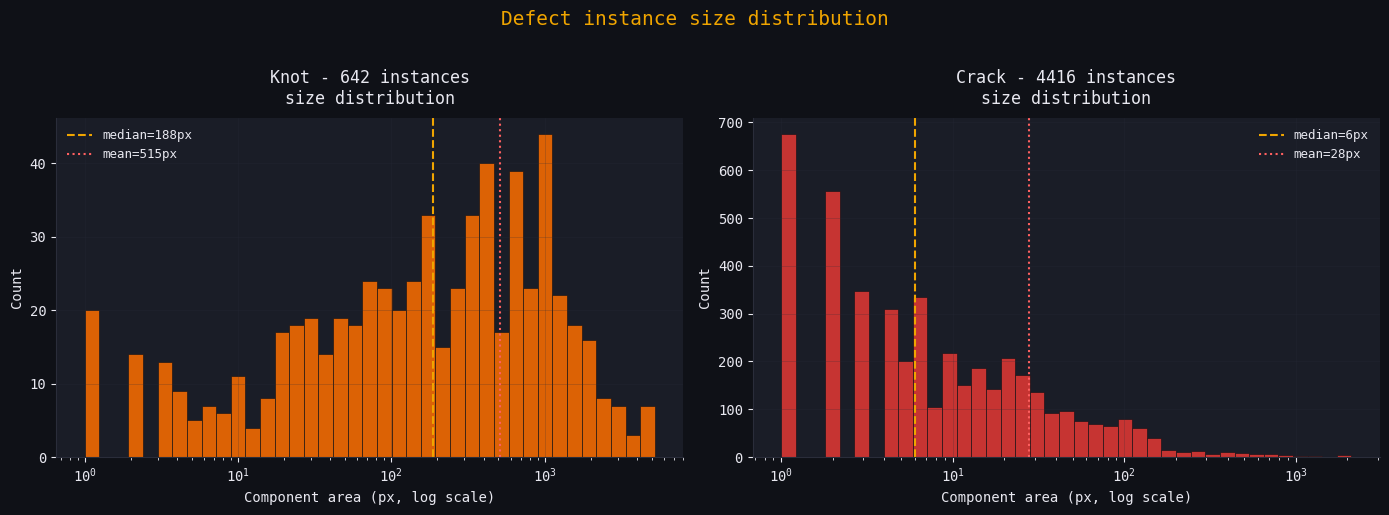

In [12]:
from scipy import ndimage

defect_classes = [c for c in all_classes if label(c) in ("Knot", "Crack")]
component_areas = defaultdict(list)  # class -> [area in px for every instance]

for _, mask_path in pairs:
    mask = np.array(Image.open(mask_path))
    for c in defect_classes:
        binary = (mask == c).astype(np.uint8)
        labeled, n_components = ndimage.label(binary)
        for comp_idx in range(1, n_components + 1):
            area = int(np.sum(labeled == comp_idx))
            component_areas[c].append(area)

fig, axes = plt.subplots(1, len(defect_classes), figsize=(7 * len(defect_classes), 5), facecolor=DARK_BG)
if len(defect_classes) == 1:
    axes = [axes]

for ax, c in zip(axes, defect_classes):
    areas = np.array(component_areas[c])
    if len(areas) == 0:
        ax.text(0.5, 0.5, "No instances found", ha="center", va="center")
        continue
    # log scale bins for wide size range
    log_bins = np.logspace(np.log10(max(1, areas.min())), np.log10(areas.max()), 40)
    ax.hist(areas, bins=log_bins, color=color(c), edgecolor=DARK_BG, linewidth=0.5, alpha=0.85)
    ax.axvline(np.median(areas), color=ACCENT, linewidth=1.5, linestyle="--",
               label=f"median={np.median(areas):.0f}px")
    ax.axvline(np.mean(areas), color="#FF6060", linewidth=1.5, linestyle=":",
               label=f"mean={np.mean(areas):.0f}px")
    ax.set_xscale("log")
    ax.set_xlabel("Component area (px, log scale)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label(c)} - {len(areas)} instances\nsize distribution", fontsize=12, pad=10)
    ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT_COL)
    ax.grid(alpha=0.3)

plt.suptitle("Defect instance size distribution", fontsize=14, color=ACCENT, y=1.02)
plt.tight_layout()
plt.show()

### Implications for modelling
- Knot and Crack require fundamentally different detection strategies:
  - Knots -> blob detection, compact circular regions, anchors 64-2000px
  - Cracks -> thin structure / line detection, elongated fragments, anchors 8-100px
- Despite the instance count growth, the median crack size remains
  6px - patch-based training with defect-centred sampling will be
  essential to ensure these tiny instances are seen during training.

Skipped 0 masks with no Wood region


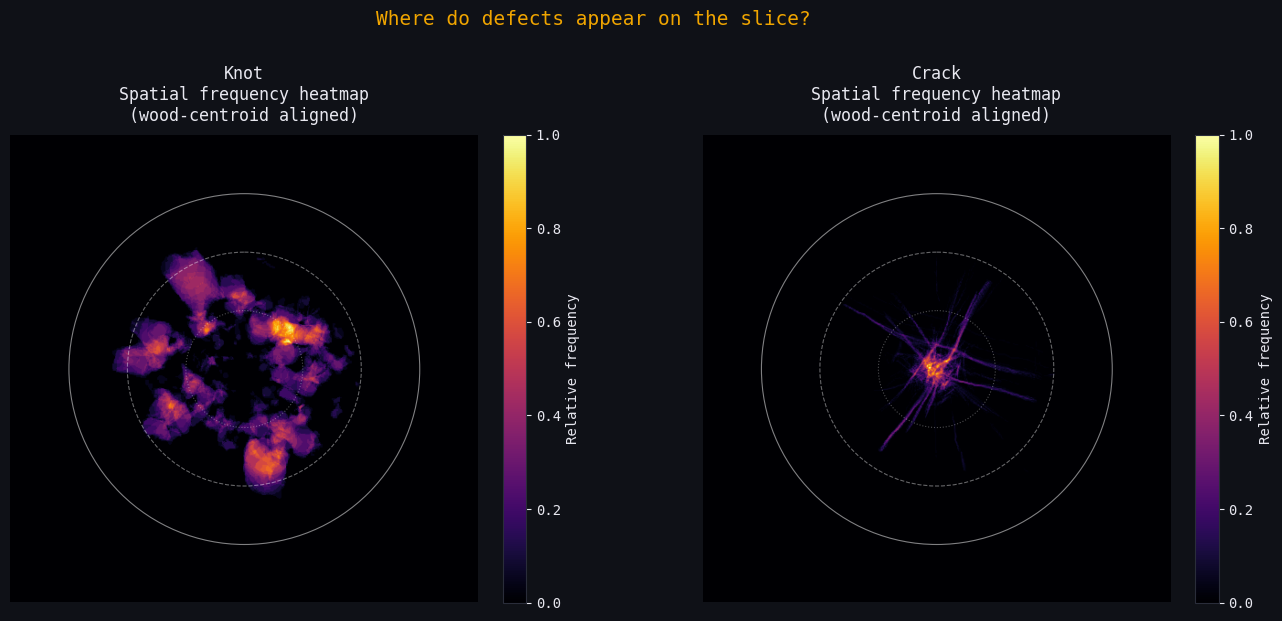

In [13]:
CANVAS_H, CANVAS_W = 512, 512
WOOD_CLASS = 3

heatmaps = {c: np.zeros((CANVAS_H, CANVAS_W), dtype=np.float32) for c in defect_classes}
skipped = 0

for _, mask_path in pairs:
    mask = np.array(Image.open(mask_path))
    H, W = mask.shape

    # resize mask to canvas first
    mask_small = np.array(
        Image.fromarray(mask.astype(np.uint8)).resize(
            (CANVAS_W, CANVAS_H), Image.NEAREST  # NEAREST to preserve class indices
        )
    )

    # find centroid of wood in the resized mask
    wood_region = (mask_small == WOOD_CLASS)
    if wood_region.sum() == 0:
        skipped += 1
        continue
    coords = np.argwhere(wood_region)
    centre_y, centre_x = coords.mean(axis=0)

    # shift each defect channel to align wood centroid
    for c in defect_classes:
        binary = (mask_small == c).astype(np.float32)
        if binary.sum() == 0:
            continue

        shift_y = int(CANVAS_H // 2 - centre_y)
        shift_x = int(CANVAS_W // 2 - centre_x)

        # use scipy shift with constant fill instead of np.roll
        # so out-of-bounds areas fill with 0 instead of wrapping
        from scipy.ndimage import shift as ndimage_shift
        shifted = ndimage_shift(binary, (shift_y, shift_x), order=1, cval=0.0)
        heatmaps[c] += shifted

print(f"Skipped {skipped} masks with no Wood region")

fig, axes = plt.subplots(1, len(defect_classes),
                         figsize=(7 * len(defect_classes), 6),
                         facecolor=DARK_BG)
if len(defect_classes) == 1:
    axes = [axes]

for ax, c in zip(axes, defect_classes):
    hm      = heatmaps[c]
    hm_norm = hm / hm.max() if hm.max() > 0 else hm
    im      = ax.imshow(hm_norm, cmap="inferno", interpolation="bilinear", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Relative frequency", color=TEXT_COL)

    cx, cy = CANVAS_W / 2, CANVAS_H / 2
    for r_pct, ls, alpha in [(0.25, ":", 0.3), (0.50, "--", 0.4), (0.75, "-", 0.5)]:
        circle = plt.Circle(
            (cx, cy), r_pct * min(CANVAS_W, CANVAS_H) / 2,
            fill=False, color="white", linewidth=0.8, linestyle=ls, alpha=alpha
        )
        ax.add_patch(circle)

    ax.set_title(f"{label(c)}\nSpatial frequency heatmap\n(wood-centroid aligned)",
                 fontsize=12, pad=10)
    ax.axis("off")

plt.suptitle("Where do defects appear on the slice?", fontsize=14, color=ACCENT, y=1.02)
plt.tight_layout()
plt.show()

### Implications for modelling
- Both heatmaps show no dominant spatial bias after centroid
  alignment - random 360° rotation + vertical/horizontal flip remains the highest priority
  augmentation to ensure the model generalises to the full range
  of crack angles and knot positions seen across all logs.
- The ring-like knot distribution confirms that centre-focused
  patch crops will undersample knots - patch sampling must cover
  the 25–75% radial zone to capture the majority of knot instances.
- The consistent radial crack origin near the pith suggests pith
  location could serve as a useful geometric prior - knowing where
  the centre is would help guide crack detection outward from that point.

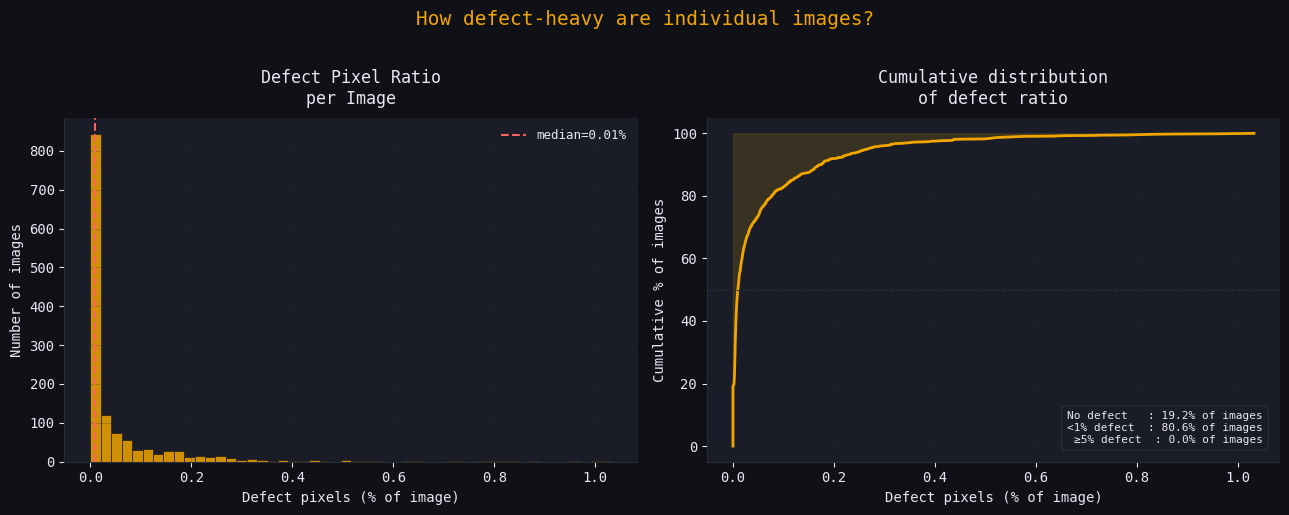

In [14]:
defect_ratios = []  # % of each image that is any defect class

for _, mask_path in pairs:
    mask = np.array(Image.open(mask_path))
    defect_px = sum(int(np.sum(mask == c)) for c in defect_classes)
    defect_ratios.append(defect_px / mask.size * 100)

defect_ratios = np.array(defect_ratios)
zero_pct  = (defect_ratios == 0).mean() * 100
light_pct = ((defect_ratios > 0) & (defect_ratios < 1)).mean() * 100
heavy_pct = (defect_ratios >= 5).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK_BG)

# Full distribution
axes[0].hist(defect_ratios, bins=50, color=ACCENT, edgecolor=DARK_BG, linewidth=0.5, alpha=0.85)
axes[0].axvline(np.median(defect_ratios), color="#FF6060", linewidth=1.5, linestyle="--",
                label=f"median={np.median(defect_ratios):.2f}%")
axes[0].set_xlabel("Defect pixels (% of image)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Defect Pixel Ratio\nper Image", fontsize=12, pad=10)
axes[0].legend(fontsize=9, framealpha=0, labelcolor=TEXT_COL)
axes[0].grid(alpha=0.3)

# Cumulative - useful for deciding sampling threshold
sorted_r = np.sort(defect_ratios)
axes[1].plot(sorted_r, np.linspace(0, 100, len(sorted_r)), color=ACCENT, linewidth=2)
axes[1].axhline(50, color=GRID_COL, linewidth=0.8, linestyle="--")
axes[1].fill_betweenx(np.linspace(0, 100, len(sorted_r)), sorted_r, alpha=0.15, color=ACCENT)
axes[1].set_xlabel("Defect pixels (% of image)")
axes[1].set_ylabel("Cumulative % of images")
axes[1].set_title("Cumulative distribution\nof defect ratio", fontsize=12, pad=10)
axes[1].grid(alpha=0.3)

# Annotation box
stats_text = (f"No defect   : {zero_pct:.1f}% of images\n"
              f"<1% defect  : {light_pct:.1f}% of images\n"
              f"≥5% defect  : {heavy_pct:.1f}% of images")
axes[1].text(0.97, 0.05, stats_text, transform=axes[1].transAxes,
             ha="right", va="bottom", fontsize=8, color=TEXT_COL,
             bbox=dict(facecolor=PANEL_BG, edgecolor=GRID_COL, boxstyle="round,pad=0.5"))

plt.suptitle("How defect-heavy are individual images?", fontsize=14, color=ACCENT, y=1.02)
plt.tight_layout()
plt.show()


### Key numbers
| Metric | Value |
|--------|-------|
| Median defect ratio | 0.01% |
| Images with no defect | 19.2% |
| Images with < 1% defect | 80.6% |
| Images with ≥ 5% defect | 0.0% |

### Key observations
- The distribution is extremely right-skewed - the vast majority
  of images contain either zero or near-zero defect pixels,
  which showcases what we have already seen in the previous plots.
- 1 in 5 images has no defect pixels at all - these are clean
  slices sitting between defect regions along the log's length.
- Every single image has less than 1% defect coverage - no image
  is heavily defective, confirming defects are always localised and
  sparse even in the most affected slices.

### Implications for modelling
- With 19.2% of images containing zero defects, a naive dataloader
  will waste roughly 1 in 5 training steps on images with no positive
  supervision signal - defect-aware batch sampling is needed to
  prevent this.
- The 0% of images with ≥5% defect coverage confirms that
  patch-based training with defect-centred crop sampling is far
  more efficient than full-image training - defect pixels will always
  be present in the model's receptive field when patches are centred
  on known defect locations.
- The median of 0.01% means the average training image contributes
  almost no defect gradient - Focal or Dice loss is most likely essential to
  prevent the background and wood classes from dominating the loss
  signal entirely.

In [15]:
import pandas as pd
from IPython.display import display

rows = []
for c in all_classes:
    areas = [v for v in class_pixel_areas[c] if v > 0]
    rows.append({
        "Class":             label(c),
        "Images with class": image_has_class[c],
        "Image repr. (%)":   round(image_has_class[c] / n_images * 100, 1),
        "Pixel share (%)":   round(pixel_counts[c] / total_px_all * 100, 3),
        "Median area (%)":   round(float(np.median(areas)), 3) if areas else 0.0,
        "Max area (%)":      round(float(np.max(areas)), 3)    if areas else 0.0,
    })

df = pd.DataFrame(rows).set_index("Class")
display(df.style
    .background_gradient(subset=["Pixel share (%)"], cmap="YlOrRd")
    .background_gradient(subset=["Image repr. (%)"], cmap="Blues")
    .format(precision=2)
)

,Images with class,Image repr. (%),Pixel share (%),Median area (%),Max area (%)
Class,,,,,
Other,2,0.10,0.00,0.02,0.04
Background,1347,100.00,79.77,81.44,88.17
Bark,1213,90.10,1.59,1.67,4.43
Wood,1347,100.00,18.58,17.00,32.39
Knot,434,32.20,0.04,0.07,1.01
Crack,959,71.20,0.01,0.01,0.39


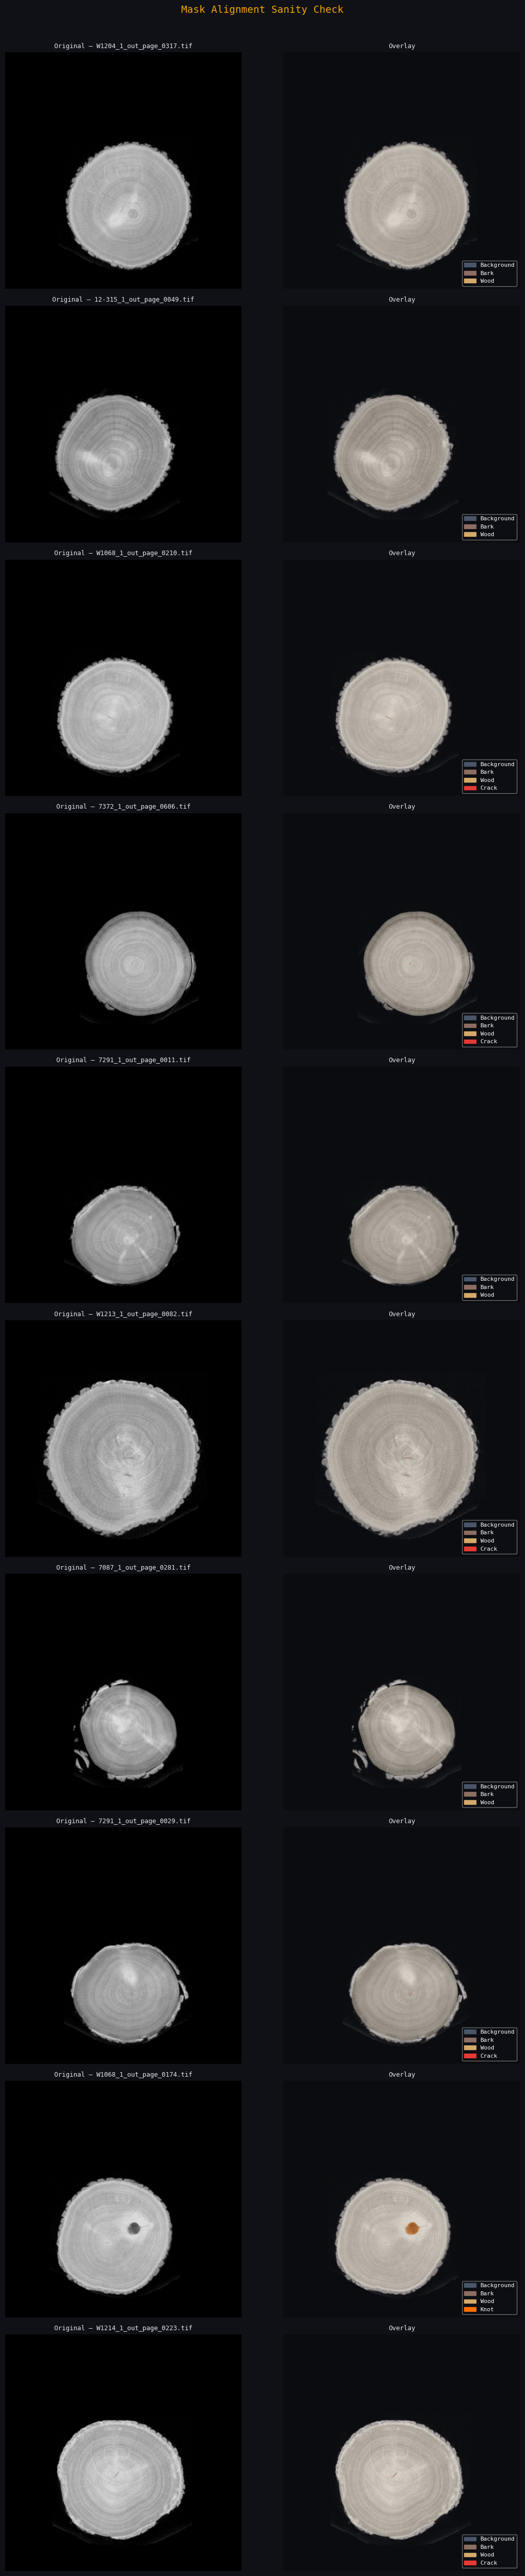

In [16]:
N_SAMPLES = 10
ALPHA     = 0.45

sample_pairs = random.sample(pairs, min(N_SAMPLES, len(pairs)))

def hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(12, 5 * N_SAMPLES), facecolor=DARK_BG)
if N_SAMPLES == 1:
    axes = [axes]

for row, (img_path, mask_path) in enumerate(sample_pairs):
    img  = np.array(Image.open(img_path).convert("RGB")) / 255.0
    mask = np.array(Image.open(mask_path))

    # ensuring mask matches image size
    if mask.shape[:2] != img.shape[:2]:
        mask = np.array(
            Image.fromarray(mask).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST
            )
        )

    colour_mask = np.zeros_like(img)
    for c in np.unique(mask):
        colour_mask[mask == c] = hex_to_rgb(color(c))

    defect_region     = np.isin(mask, defect_classes)
    non_defect_region = ~defect_region

    blended = img.copy()
    blended[defect_region]     = (1 - ALPHA) * img[defect_region]     + ALPHA * colour_mask[defect_region]
    blended[non_defect_region] = 0.85 * img[non_defect_region] + 0.15 * colour_mask[non_defect_region]

    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Original — {os.path.basename(img_path)}", fontsize=9, pad=6)
    axes[row][0].axis("off")

    axes[row][1].imshow(blended)
    axes[row][1].set_title("Overlay", fontsize=9, pad=6)
    axes[row][1].axis("off")

    present_classes = np.unique(mask)
    axes[row][1].legend(
        handles=[Patch(color=hex_to_rgb(color(c)), label=label(c)) for c in present_classes],
        fontsize=8, loc="lower right", framealpha=0.5,
        facecolor=DARK_BG, labelcolor="white"
    )

plt.suptitle("Mask Alignment Sanity Check", fontsize=14, color=ACCENT, y=1.005)
plt.tight_layout()
plt.show()